# Práctica: DBSCAN, GMM y SOM con datos sintéticos

## Objetivo

Comparar tres métodos de agrupamiento sobre el mismo conjunto de datos sintético con estructura no convexa:

- DBSCAN
- Gaussian Mixture Model (GMM)
- Self-Organizing Map (SOM) + K-Means sobre los prototipos

La práctica busca analizar:

- cómo influye la geometría de los datos en cada método;
- cómo afectan los hiperparámetros al resultado;
- cómo comparar configuraciones mediante métricas internas;
- cómo construir un ranking multicriterio;
- cómo utilizar el porcentaje de ruido en DBSCAN;
- cómo interpretar el resultado de SOM como una representación basada en prototipos;
- y, únicamente al final, cómo comparar con las etiquetas reales mediante ARI.


## 1. Importación de librerías


In [6]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score)

try:
    from minisom import MiniSom
except ImportError:
    !pip -q install minisom
    from minisom import MiniSom


## 2. Construcción del conjunto de datos sintético

Se utilizan dos grupos con forma de medias lunas. Esta geometría es deliberadamente no convexa y permite observar diferencias claras entre métodos basados en densidad, modelos gaussianos y mapas autoorganizados.


In [7]:
X, y_real = make_moons(n_samples=400, noise=0.05, random_state=42)

In [8]:
print("Dimensiones de X:", X.shape)
print("Número de observaciones por grupo real:", np.bincount(y_real))

Dimensiones de X: (400, 2)
Número de observaciones por grupo real: [200 200]


### 2.1. Visualización de los datos originales

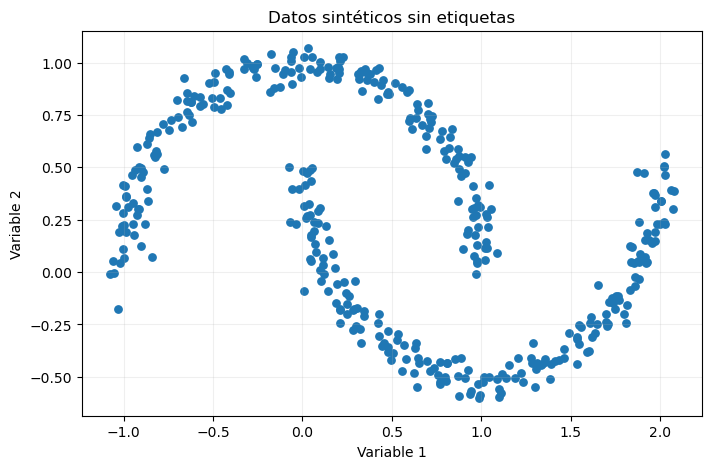

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], s=28)
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.title("Datos sintéticos sin etiquetas")
plt.grid(alpha=0.2)
plt.show()

### Preguntas

Observando únicamente la geometría:

1. ¿Cuántos clusters parecen existir?
2. ¿Qué método cree que podría adaptarse mejor a la forma de medias lunas?
3. ¿Qué dificultades podrían tener GMM o SOM + K-Means?


## 3. Estandarización

Se estandarizan las variables para que las distancias y el entrenamiento de SOM no estén dominados por diferencias de escala.

$$
z = \frac{x-\mu}{\sigma}
$$


In [ ]:
# Complete la creación del escalador y la transformación
# scaler = __________()
# X_scaled = scaler.__________(X)

print("Media aproximada:", X_scaled.mean(axis=0))
print("Desviación estándar aproximada:", X_scaled.std(axis=0))

# Evaluación cuantitativa

## 4. Funciones auxiliares

Se utilizarán:

- SSE ↓
- Silhouette ↑
- Davies-Bouldin ↓
- Calinski-Harabasz ↑

Para DBSCAN, las métricas internas se calculan únicamente sobre los puntos que no son ruido.

El ranking multicriterio asignará una posición a cada configuración en cada métrica. La menor suma de posiciones será considerada el mejor compromiso.


In [ ]:
def calcular_sse(X_array, labels):
    sse = 0.0

    for cluster in np.unique(labels):
        if cluster == -1:
            continue

        puntos = X_array[labels == cluster]
        centroide = puntos.mean(axis=0)
        sse += np.sum((puntos - centroide) ** 2)

    return sse


def evaluar_clustering(X_array, labels):
    labels = np.asarray(labels)

    if -1 in labels:
        mascara = labels != -1
        X_eval = X_array[mascara]
        labels_eval = labels[mascara]
    else:
        X_eval = X_array
        labels_eval = labels

    n_clusters = len(np.unique(labels_eval))

    if n_clusters < 2:
        return None

    return {
        "n_clusters": n_clusters,
        "Ruido (%)": 100 * np.mean(labels == -1),
        "SSE ↓": calcular_sse(X_array, labels),
        # Complete las tres métricas:
        #"Silhouette ↑": _______________________________,
        #"Davies-Bouldin ↓": ___________________________,
        #"Calinski-Harabasz ↑": ________________________
    }


def construir_ranking(df):
    ranking = df.copy()

    ranking["Rank_SSE"] = ranking["SSE ↓"].rank(ascending=True, method="min")
    ranking["Rank_Silhouette"] = ranking["Silhouette ↑"].rank(ascending=False, method="min")
    ranking["Rank_DB"] = ranking["Davies-Bouldin ↓"].rank(ascending=True, method="min")
    ranking["Rank_CH"] = ranking["Calinski-Harabasz ↑"].rank(ascending=False, method="min")
    columnas_rank = ["Rank_SSE", "Rank_Silhouette", "Rank_DB", "Rank_CH"]
    
    ranking["Rank_Ruido"] = ranking["Ruido (%)"].rank(ascending=True, method="min")
    columnas_rank.append("Rank_Ruido")

    ranking["Rank_Total"] = ranking[columnas_rank].sum(axis=1)
    ranking = ranking.sort_values(["Rank_Total", "Silhouette ↑"], ascending=[True, False]).reset_index(drop=True)
    ranking["Posición"] = ranking.index + 1

    return ranking

# DBSCAN

## 5. Configuración inicial

Inicialmente se utilizará:
eps = 0.15
min_samples = 10

Esta configuración no necesariamente será la mejor.

### Actividad

Evalúe distintas combinaciones:

eps_values = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35]

min_samples_values = [3, 5, 8, 10]

Conserve únicamente configuraciones con:

- al menos 2 clusters;
- no más de 50% de ruido.

Construya posteriormente un ranking que incluya también Ruido (%).


In [ ]:
# Complete la creación y entrenamiento de DBSCAN
# dbscan_inicial = __________(eps=0.15, min_samples=10)

# labels_dbscan_inicial = dbscan_inicial.__________(X_scaled)

print(pd.Series(labels_dbscan_inicial).value_counts().sort_index())
eval_inicial_dbscan = evaluar_clustering(X_scaled, labels_dbscan_inicial)
pd.DataFrame([eval_inicial_dbscan]).round(3)

### Pregunta
1. ¿Los datos quedaron bien repartidos en los clusters resultantes?

In [ ]:
# Valores sugeridos para evaluar
# eps_values = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35]
# min_samples_values = [3, 5, 8, 10]

filas = []
dbscan_models = {}

for eps in eps_values:
    for min_samples in min_samples_values:

        modelo = DBSCAN(eps=eps, min_samples=min_samples)
        #labels = modelo.fit_predict(_______)

        metricas = evaluar_clustering(X_scaled, labels)

        if metricas is None:
            continue

        filas.append({"eps": eps,"min_samples": min_samples,**metricas})
        dbscan_models[(eps, min_samples)] = labels

dbscan_results = pd.DataFrame(filas)
#Filtre los resultados para que solo queden los resultados con más de dos clusters y con menos del 50% de los datos etiquetados como ruído
#dbscan_valid = dbscan_results[(dbscan_results["n_clusters"] > 2) & (dbscan_results["Ruido (%)"] <= _)].copy()

dbscan_ranking = construir_ranking(dbscan_valid, incluir_ruido=True)
dbscan_ranking.round(3)

In [ ]:
# Seleccione la primera fila del ranking
# best_dbscan = ______________________

best_eps = float(best_dbscan["eps"])
best_min_samples = int(best_dbscan["min_samples"])
labels_dbscan = dbscan_models[(best_eps, best_min_samples)]

print("Mejor configuración DBSCAN")
print("eps:", best_eps)
print("min_samples:", best_min_samples)

## Pregunta
1. ¿Hay configuraciones de hiperparámetros que generen mejor resultados que los anteriores para DBSCAN?
2. ¿Considera que los mejores resultados seleccionados realmente corresponden a buenos resultados?

# Gaussian Mixture Model (GMM)

## 6. Configuración inicial

Utilicemos `covariance_type="full"` y evaluemos la siguiente combinación de hiperparámetros:

n_components = 3
n_init = 5

### Actividad

Evalúe combinaciones como:
k_values = [2, 3, 4, 5]
n_init_values = [5, 10, 20]

Construya una tabla con las métricas y luego un ranking multicriterio.

In [ ]:
# Complete la creación, entrenamiento y predicción
# gmm_inicial = __________(n_components=3, covariance_type="full", n_init=5, random_state=42)

# gmm_inicial.__________(X_scaled)
# labels_gmm_inicial = gmm_inicial.__________(X_scaled)

pd.DataFrame([evaluar_clustering(X_scaled, labels_gmm_inicial)]).round(3)

In [ ]:
# Valores sugeridos
# k_values = [2, 3, 4, 5]
# n_init_values = [5, 10, 20]

filas = []
gmm_models = {}

for k in k_values:
    for n_init in n_init_values:

        #modelo = GaussianMixture(n_components=__, covariance_type="full", n_init=___, random_state=42)

        modelo.fit(X_scaled)
        labels = modelo.predict(X_scaled)

        metricas = evaluar_clustering(X_scaled, labels
        )

        filas.append({"k": k, "n_init": n_init, **metricas})

        gmm_models[(k, n_init)] = {"model": modelo, "labels": labels}

gmm_results = pd.DataFrame(filas)

gmm_ranking = construir_ranking(gmm_results)

gmm_ranking.round(3)

In [ ]:
best_gmm = gmm_ranking.iloc[0]
# Complete:
# best_gmm_k = _____________________
# best_gmm_n_init = ________________
# selected_gmm = ___________________
# labels_gmm = _____________________

print("Mejor configuración GMM")
print("k:", best_gmm_k)
print("n_init:", best_gmm_n_init)

## Pregunta
1. ¿Qué tanto mejoró los resultados con respecto a la configuración inicial para GMM?

# Self-Organizing Map (SOM)

## 7. Configuración inicial

El SOM aprende una rejilla de prototipos. Para obtener una partición explícita, se aplica K-Means sobre los pesos de las neuronas.

Configuración inicial:

```python
mapa = 4x4
sigma = 0.5
learning_rate = 0.1
k = 3
```

### Actividad

Evalúe combinaciones como:

```python
# map_sizes = [(4, 4), (6, 6)]
# sigma_values = [0.5, 1.0, 1.5]
# learning_rates = [0.1, 0.5]
# k_values = [2, 3, 4]
```

Entrene el SOM una sola vez por combinación de tamaño, `sigma` y `learning_rate`; luego pruebe diferentes valores de `k` sobre los mismos prototipos.


In [ ]:
def labels_from_som_and_kmeans(som, X_array, n_clusters, random_state=42):
   
    pesos = som.get_weights()
    map_x, map_y, n_features = pesos.shape

    prototipos = pesos.reshape(map_x * map_y, n_features)

    # Complete la creación de K-Means:
    # kmeans = __________(n_clusters=__________, n_init=20, random_state=random_state)

    kmeans.fit(prototipos)
    clusters_neuronas = kmeans.labels_.reshape(map_x, map_y)
    labels = np.array([clusters_neuronas[som.winner(x)] for x in X_array])

    return labels, kmeans, clusters_neuronas

In [ ]:
# Complete la creación y entrenamiento del SOM
# som_inicial = MiniSom(x=4, y=4, input_len=__________________, sigma=0.5, learning_rate=0.1, neighborhood_function="gaussian",
#                       random_seed=42)

som_inicial.train_random(X_scaled, num_iteration=1500)

labels_som_inicial, _, _ = (labels_from_som_and_kmeans(som_inicial, X_scaled, n_clusters=3))

pd.DataFrame([evaluar_clustering(X_scaled, labels_som_inicial)]).round(3)


In [ ]:
# Valores sugeridos:
# map_sizes = [(4, 4), (6, 6)]
# sigma_values = [0.5, 1.0, 1.5]
# learning_rates = [0.1, 0.5]
# k_values = [2, 3, 4]

filas = []
som_models = {}

for map_x, map_y in map_sizes:
    for sigma in sigma_values:
        for learning_rate in learning_rates:

            #som = MiniSom(
                #x=____,
                #y=____,
                input_len=X_scaled.shape[1],
                #sigma=______,
                #learning_rate=_________,
                neighborhood_function="gaussian",
                random_seed=42
            )

            som.train_random(X_scaled, num_iteration=1500)

            for k in k_values:

                labels, kmeans, clusters_neuronas = (labels_from_som_and_kmeans(som, X_scaled, n_clusters=k))

                metricas = evaluar_clustering(X_scaled, labels)

                filas.append({
                    "mapa": f"{map_x}x{map_y}",
                    "map_x": map_x,
                    "map_y": map_y,
                    "sigma": sigma,
                    "learning_rate": learning_rate,
                    "k": k,
                    **metricas
                })

                clave = (map_x, map_y, sigma, learning_rate, k)

                som_models[clave] = {
                    "som": som,
                    "kmeans": kmeans,
                    "clusters_neuronas": clusters_neuronas,
                    "labels": labels
                }

som_results = pd.DataFrame(filas)
som_ranking = construir_ranking(som_results)
som_ranking.round(3)

In [ ]:
best_som = som_ranking.iloc[0]

best_map_x = int(best_som["map_x"])
best_map_y = int(best_som["map_y"])
best_sigma = float(best_som["sigma"])
best_learning_rate = float(best_som["learning_rate"])
best_som_k = int(best_som["k"])

best_som_key = (best_map_x, best_map_y, best_sigma, best_learning_rate, best_som_k)

selected_som = som_models[best_som_key]
labels_som = selected_som["labels"]

print("Mejor configuración SOM")
print("Mapa:", f"{best_map_x}x{best_map_y}")
print("sigma:", best_sigma)
print("learning_rate:", best_learning_rate)
print("k:", best_som_k)

# Comparación visual

## 8. Mejores configuraciones

Visualice las mejores particiones encontradas para DBSCAN, GMM y SOM.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

configuraciones = [
    ("DBSCAN", labels_dbscan),
    ("GMM", labels_gmm),
    ("SOM + K-Means", labels_som)
]

for ax, (nombre, labels) in zip(axes, configuraciones):
    ax.scatter(
        X_scaled[:, 0],
        X_scaled[:, 1],
        c=labels,
        s=24,
        cmap="viridis"
    )
    ax.set_title(nombre)
    ax.set_xlabel("Variable 1")
    ax.set_ylabel("Variable 2")
    ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()


# Evaluación cuantitativa final

## 9. Tabla comparativa

Compare las mejores configuraciones de los tres métodos mediante las métricas internas.


In [ ]:
resultados_finales = []

for nombre, labels in [
    ("DBSCAN", labels_dbscan),
    ("GMM", labels_gmm),
    ("SOM + K-Means", labels_som)
]:

    metricas = evaluar_clustering(X_scaled, labels)
    resultados_finales.append({"Método": nombre, **metricas})

resultados_finales_df = pd.DataFrame(resultados_finales)

resultados_finales_df.round(3)

## Pregunta
1. ¿Qué muestran estos resultados?, interpretelos.

# Validación externa

## 10. Adjusted Rand Index (ARI)

Como los datos son sintéticos, conocemos `y_real`. Esta variable no se utiliza para seleccionar hiperparámetros.

Solo al final se calcula:

$$
ARI \approx 1
$$

cuando la partición encontrada coincide fuertemente con la estructura real.


In [ ]:
ari_resultados = []

for nombre, labels in [
    ("DBSCAN", labels_dbscan),
    ("GMM", labels_gmm),
    ("SOM + K-Means", labels_som)
]:
    ari_resultados.append({
        "Método": nombre,
        "ARI ↑": adjusted_rand_score(
            y_real,
            labels
        )
    })

ari_df = pd.DataFrame(ari_resultados)
ari_df.round(3)

### Preguntas de análisis

1. ¿Qué método recuperó mejor visualmente las dos lunas?
2. ¿Qué ocurrió con el porcentaje de ruido al aumentar `eps`?
3. ¿GMM logró representar correctamente la estructura no convexa? Explique.
5. ¿Qué efecto tuvieron `sigma`, `learning_rate` y tamaño del mapa en SOM?
6. ¿La configuración con mejores métricas internas coincidió siempre con la mayor ARI?
7. ¿Qué método entre los vistos en clases incluyendo K-Means y jerárquico considera más apropiado para este tipo de geometría y por qué?
